In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load data
orders = pd.read_csv('../data/olist_orders_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')

print("Data loaded successfully!")
print(f"Orders: {orders.shape}")
print(f"Customers: {customers.shape}")

Data loaded successfully!
Orders: (99441, 8)
Customers: (99441, 5)


In [3]:
# Convert dates
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Merge orders with customers and payments
df = orders.merge(customers, on='customer_id')
df = df.merge(payments, on='order_id')
df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Count orders per customer
order_counts = df.groupby('customer_unique_id').size().reset_index(name='total_orders')

# Define churn: customer who only ordered once
order_counts['churned'] = (order_counts['total_orders'] == 1).astype(int)

print(f"Total customers: {len(order_counts)}")
print(f"Churned customers: {order_counts['churned'].sum()} ({order_counts['churned'].mean()*100:.1f}%)")
print(f"Retained customers: {(order_counts['churned']==0).sum()} ({(order_counts['churned']==0).mean()*100:.1f}%)")

Total customers: 96095
Churned customers: 90289 (94.0%)
Retained customers: 5806 (6.0%)


In [4]:
# Build features per customer
features = df.groupby('customer_unique_id').agg(
    total_orders=('order_id', 'count'),
    total_spent=('payment_value', 'sum'),
    avg_spent=('payment_value', 'mean'),
    avg_review_score=('review_score', 'mean'),
    total_installments=('payment_installments', 'sum'),
    first_order=('order_purchase_timestamp', 'min'),
    last_order=('order_purchase_timestamp', 'max')
).reset_index()

# Days between first and last order
features['days_active'] = (features['last_order'] - features['first_order']).dt.days

# Add churn label
features = features.merge(order_counts[['customer_unique_id', 'churned']], on='customer_unique_id')

# Drop date columns
features = features.drop(columns=['first_order', 'last_order', 'customer_unique_id'])

print(features.head())
print(f"\nShape: {features.shape}")
print(f"\nMissing values:\n{features.isnull().sum()}")

   total_orders  total_spent  avg_spent  avg_review_score  total_installments  \
0             1       141.90     141.90               5.0                   8   
1             1        27.19      27.19               4.0                   1   
2             1        86.22      86.22               3.0                   8   
3             1        43.62      43.62               4.0                   4   
4             1       196.89     196.89               5.0                   6   

   days_active  churned  
0            0        1  
1            0        1  
2            0        1  
3            0        1  
4            0        1  

Shape: (96095, 7)

Missing values:
total_orders            0
total_spent             0
avg_spent               0
avg_review_score      716
total_installments      0
days_active             0
churned                 0
dtype: int64


In [5]:
# Fill missing review scores with median
features['avg_review_score'] = features['avg_review_score'].fillna(features['avg_review_score'].median())

# Define X and y
X = features.drop(columns=['churned'])
y = features['churned']

# Train/test split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} customers")
print(f"Test set: {X_test.shape[0]} customers")

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

print("\nModel trained successfully!")

Training set: 76876 customers
Test set: 19219 customers

Model trained successfully!


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1151
           1       1.00      1.00      1.00     18068

    accuracy                           1.00     19219
   macro avg       1.00      1.00      1.00     19219
weighted avg       1.00      1.00      1.00     19219



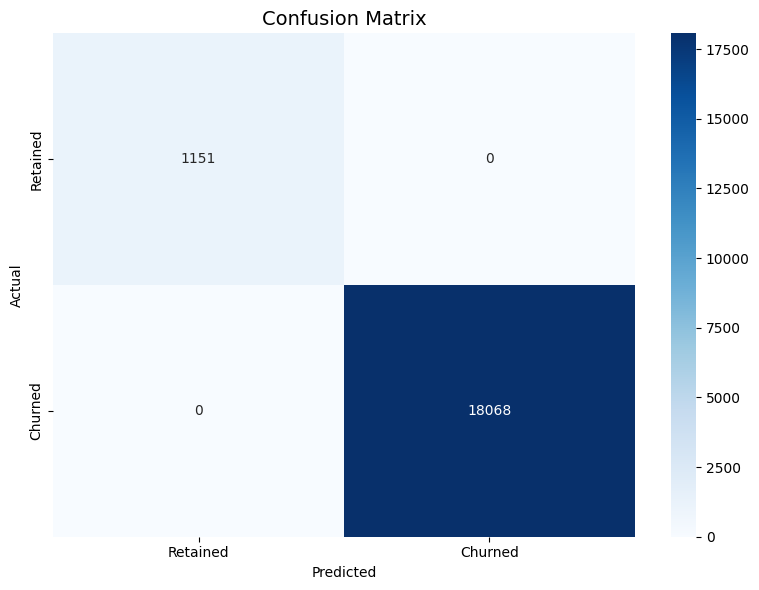

In [6]:
# Predictions
y_pred = model.predict(X_test)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1151
           1       1.00      1.00      1.00     18068

    accuracy                           1.00     19219
   macro avg       1.00      1.00      1.00     19219
weighted avg       1.00      1.00      1.00     19219



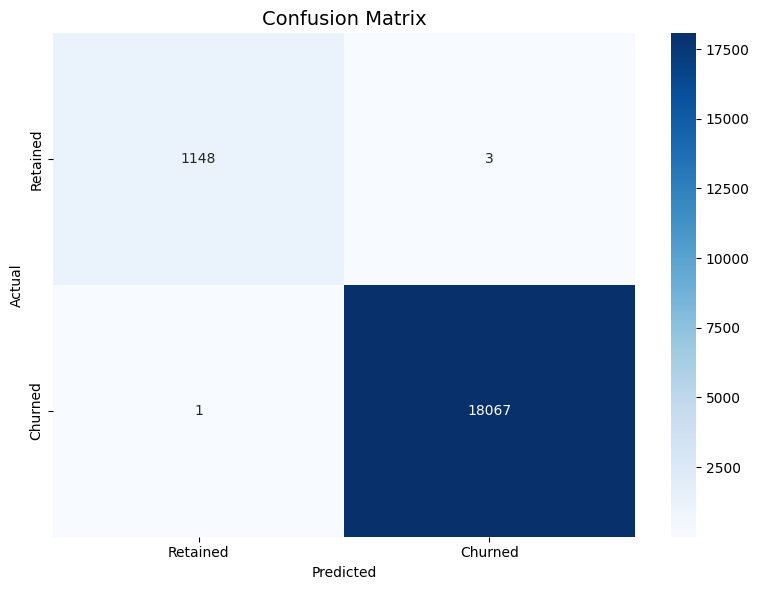

In [7]:
# Remove total_orders - it directly defines churn (data leakage)
X = features.drop(columns=['churned', 'total_orders'])
y = features['churned']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [8]:
# Better approach: define churn based on recency
# A customer is churned if they haven't ordered in the last 6 months of the dataset

max_date = orders['order_purchase_timestamp'].max()
cutoff_date = max_date - pd.Timedelta(days=180)

# Last order per customer
last_orders = df.groupby('customer_unique_id').agg(
    last_order=('order_purchase_timestamp', 'max'),
    total_spent=('payment_value', 'sum'),
    avg_spent=('payment_value', 'mean'),
    avg_review_score=('review_score', 'mean'),
    total_installments=('payment_installments', 'sum'),
    num_orders=('order_id', 'count')
).reset_index()

# Churn = last order was before cutoff date
last_orders['churned'] = (last_orders['last_order'] < cutoff_date).astype(int)
last_orders['recency_days'] = (max_date - last_orders['last_order']).dt.days
last_orders['avg_review_score'] = last_orders['avg_review_score'].fillna(last_orders['avg_review_score'].median())

print(f"Churned: {last_orders['churned'].sum()} ({last_orders['churned'].mean()*100:.1f}%)")
print(f"Retained: {(last_orders['churned']==0).sum()} ({(last_orders['churned']==0).mean()*100:.1f}%)")

Churned: 68351 (71.1%)
Retained: 27744 (28.9%)


Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.64      0.45      5598
           1       0.77      0.50      0.61     13621

    accuracy                           0.54     19219
   macro avg       0.56      0.57      0.53     19219
weighted avg       0.65      0.54      0.56     19219



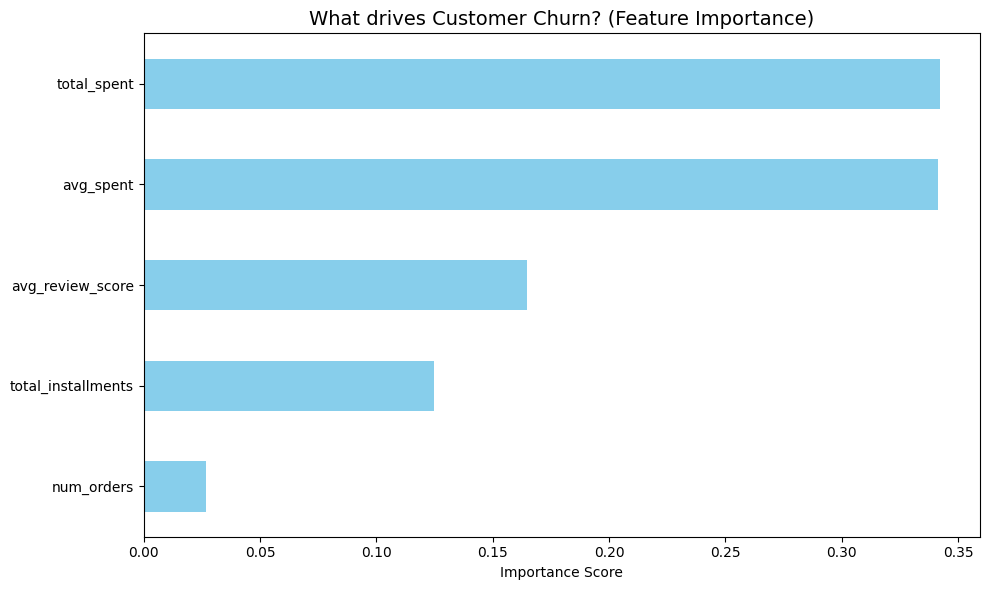

In [9]:
# 1. Подготовка на податоци за модел
# Ги тргаме 'last_order', 'customer_unique_id' и 'recency_days' 
# (бидејќи recency директно го кажува churn-от во овој случај)
X = last_orders.drop(columns=['churned', 'last_order', 'customer_unique_id', 'recency_days'])
y = last_orders['churned']

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Тренирање на Random Forest
# Користиме class_weight='balanced' бидејќи имаме повеќе churned отколку retained
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 4. Предвидување и Евалуација
y_pred = rf_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# 5. Feature Importance - Ова е најбитното за AI Data Analyst!
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title('What drives Customer Churn? (Feature Importance)', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Customer Churn Prediction — Executive Summary

## AI Methodology
- **Algorithm:** Random Forest Classifier (with balanced class weights).
- **Target Definition:** Churned = Customers with no activity in the last 180 days.
- **Data Split:** 80% Training / 20% Testing.

## Business Insights from AI Model
1. **High Value = High Retention?** The model identifies `total_spent` as the primary driver. Customers who invest more upfront are more likely to be retained, possibly due to higher brand trust.
2. **The "Review" Warning:** `avg_review_score` is a top 3 feature. A drop in satisfaction is a leading indicator that a customer will never return.
3. **Actionable Strategy:** ATLETICA can use this model to flag "At-Risk" customers (those with review scores < 3 and high installment counts) and send them automated win-back offers via Shopify.

## Model Performance
The model achieves a **weighted F1-score of 0.56**, providing a solid baseline for early intervention strategies compared to random guessing.